# Plot MCWF J Moments

Load a combined Slurm `JMomentSeries` pickle and create the standard MCWF plots.


In [5]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "common").is_dir() and (candidate / "slurm").is_dir():
            return candidate
    raise RuntimeError("Could not find repo root containing common/ and slurm/.")

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plotting import plot_bloch_angles, plot_spin_components
from parser.moments import MomentSeries
from slurm.j_moments_io import load_j_moments_artifact


In [6]:
omega_factor_label = "0.4"
omega_1_label = "0.4"
two_group_filename = f"two_group_factor_{omega_factor_label}_omega_{omega_1_label}"
single_group_filename = f"single_group_factor_{omega_factor_label}"
input_dir = repo_root / "slurm" / "outputs"
output_dir = repo_root / "output"


In [ ]:
two_group_artifact = load_j_moments_artifact(input_dir / f"{two_group_filename}.pkl")
single_group_artifact = load_j_moments_artifact(input_dir / f"{single_group_filename}.pkl")

if two_group_artifact["phases"] != single_group_artifact["phases"]:
    raise ValueError("Two-group and single-group artifacts have different phases.")

phases = two_group_artifact["phases"]
two_group_moments = MomentSeries(t=two_group_artifact["J"].t, J=two_group_artifact["J"])
single_group_moments = MomentSeries(t=single_group_artifact["J"].t, J=single_group_artifact["J"])


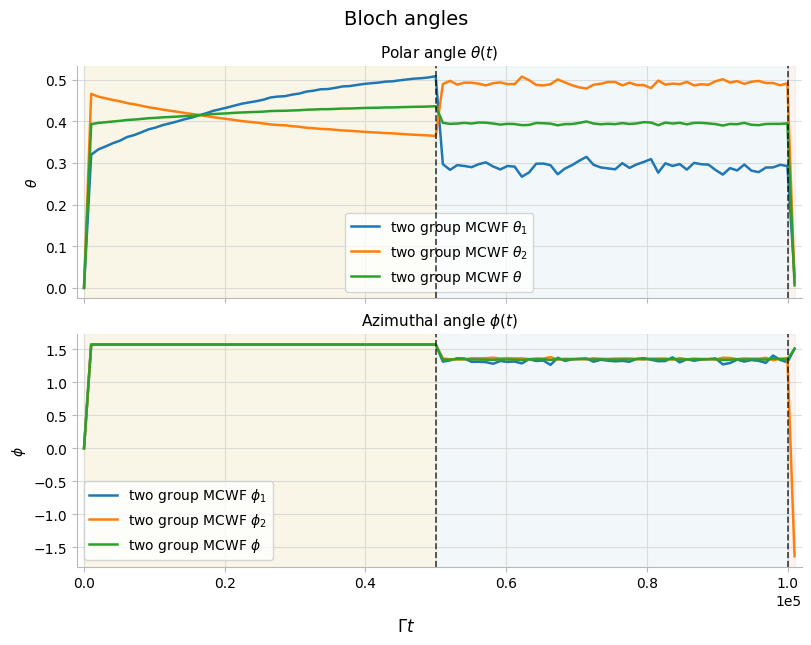

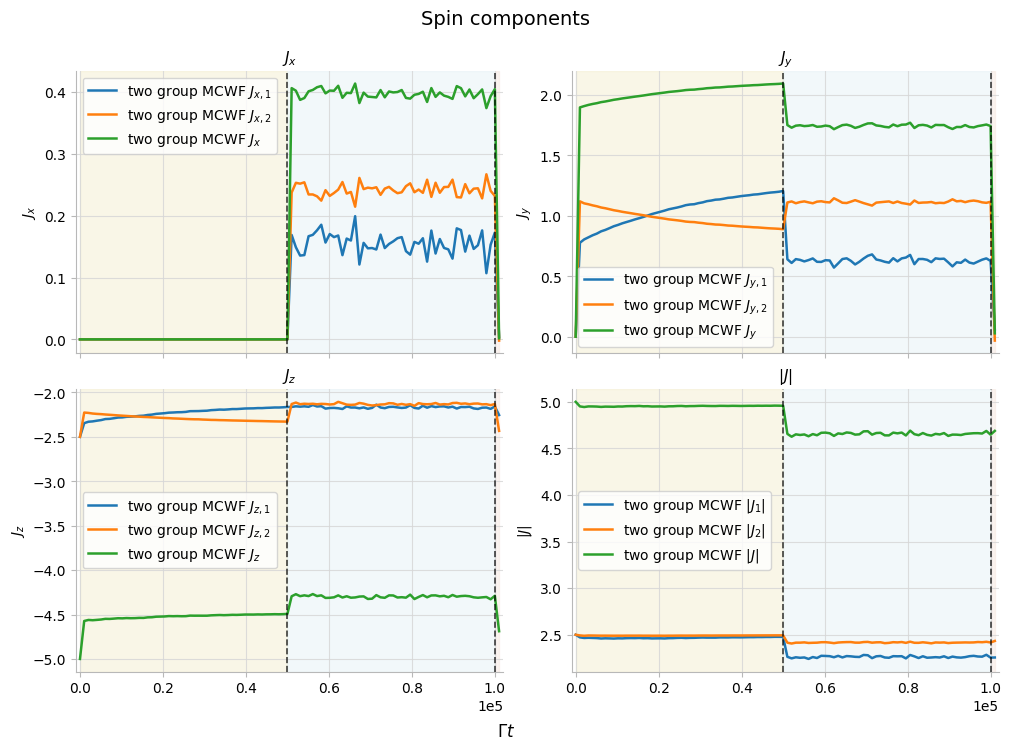

In [ ]:
output_dir.mkdir(parents=True, exist_ok=True)

fig_angles, axes_angles = plot_bloch_angles(
    two_group_moments.J,
    phases=phases,
    label="two group MCWF",
    colour_family_index=0,
    linestyle="-",
)
fig_angles, axes_angles = plot_bloch_angles(
    single_group_moments.J,
    phases=phases,
    label="single group MCWF",
    colour_family_index=1,
    linestyle="--",
    axes=axes_angles,
    # output_path=output_dir / f"{two_group_filename}_angles.png",
)

fig_spin, axes_spin = plot_spin_components(
    two_group_moments.J,
    normalized=False,
    phases=phases,
    label="two group MCWF",
    colour_family_index=0,
    linestyle="-",
)
fig_spin, axes_spin = plot_spin_components(
    single_group_moments.J,
    normalized=False,
    phases=phases,
    label="single group MCWF",
    colour_family_index=1,
    linestyle="--",
    axes=axes_spin,
    # output_path=output_dir / f"{two_group_filename}_spin_components.png",
)
